# Feature Engineering based on Analyis done so far.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r'D:\Shorya\python\EDA Practice csv\hotel_bookings.csv')
df.sample(4)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
6001,Resort Hotel,0,237,2016,May,21,19,2,8,2,...,No Deposit,40.0,NaN,0,Contract,58.95,0,0,Check-Out,2016-05-29
99652,City Hotel,0,335,2016,October,42,13,0,3,1,...,No Deposit,56.0,NaN,0,Transient-Party,0.00,0,0,Check-Out,2016-10-16
87171,City Hotel,0,75,2016,April,16,11,1,3,2,...,No Deposit,9.0,NaN,0,Transient,90.95,0,1,Check-Out,2016-04-15
104958,City Hotel,0,17,2017,January,4,27,0,0,2,...,No Deposit,9.0,NaN,0,Transient,0.00,0,0,Check-Out,2017-01-27


## Total Guests

Combines adults, children, and babies into a single occupancy feature.

In [3]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']

<Axes: xlabel='total_guests', ylabel='Count'>

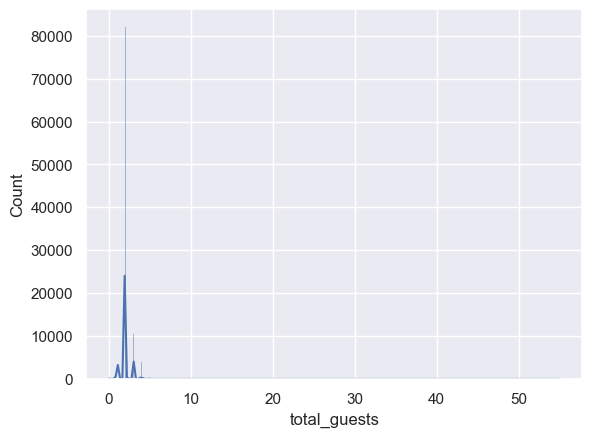

In [4]:
sns.set_style()
sns.set_theme(style='darkgrid')
sns.histplot(x='total_guests',data=df,kde=True)

In [5]:
df['total_guests'].describe()

count    119386.000000
mean          1.968229
std           0.722400
min           0.000000
25%           2.000000
50%           2.000000
75%           2.000000
max          55.000000
Name: total_guests, dtype: float64

## Total Stay Duration

Combine weekday + weekend nights.

In [6]:
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

<Axes: xlabel='total_nights', ylabel='Count'>

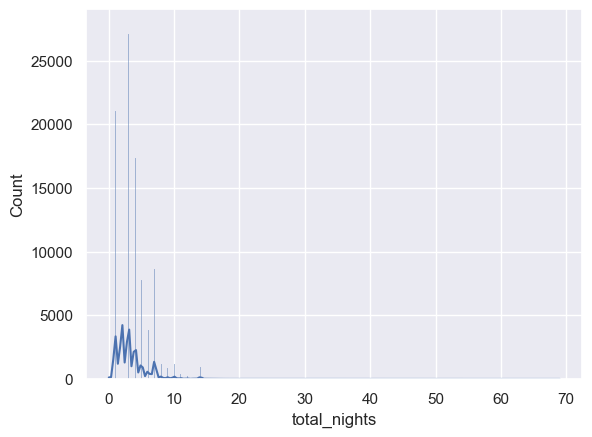

In [7]:
sns.histplot(x='total_nights',data=df,kde=True)

In [8]:
df['total_nights'].describe()

count    119390.000000
mean          3.427900
std           2.557439
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          69.000000
Name: total_nights, dtype: float64

## Family Booking Flag

Binary indicator for family travel. Family bookings often behave differently
,can reduce noise from sparse children/babies columns

In [9]:
import numpy as np
df['is_family'] = np.where(
    (df['children'] > 0) | (df['babies'] > 0),
    1,
    0
)

<Axes: xlabel='is_family', ylabel='count'>

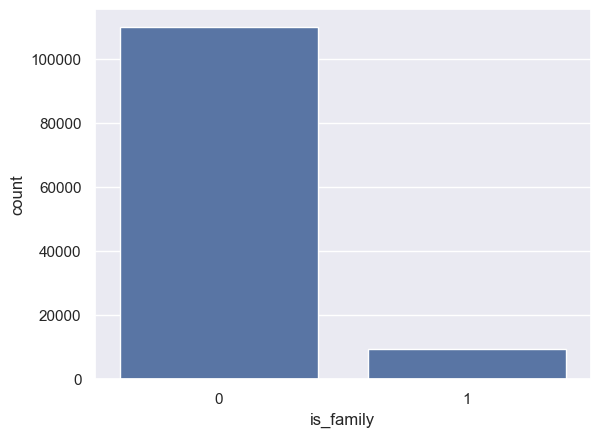

In [10]:
sns.countplot(x='is_family',data=df)

## Previous Cancellation Ratio

Measures customer reliability, converts raw counts into behavioral probability, much more informative than raw counts

In [11]:
df['prev_cancel_ratio'] = (
    df['previous_cancellations'] /
    (df['previous_cancellations'] + df['previous_bookings_not_canceled'] + 1)
)

<Axes: xlabel='prev_cancel_ratio', ylabel='Count'>

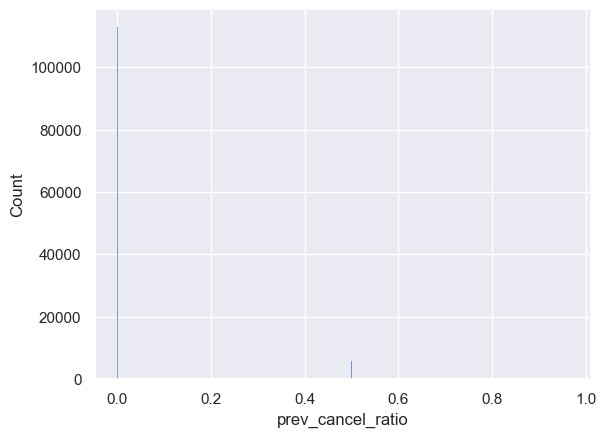

In [12]:
sns.histplot(x='prev_cancel_ratio',data=df)

In [13]:
df['prev_cancel_ratio'].value_counts()

prev_cancel_ratio
0.000000    112906
0.500000      5676
0.333333        64
0.200000        48
0.960000        48
             ...  
0.300000         1
0.217391         1
0.208333         1
0.192308         1
0.185185         1
Name: count, Length: 122, dtype: int64

## Booking Changes Flag

Customers who modify reservations may be more engaged, sometimes associated with lower cancellation risk

In [14]:
df['has_booking_changes'] = np.where(df['booking_changes'] > 0, 1, 0)

<Axes: xlabel='has_booking_changes', ylabel='count'>

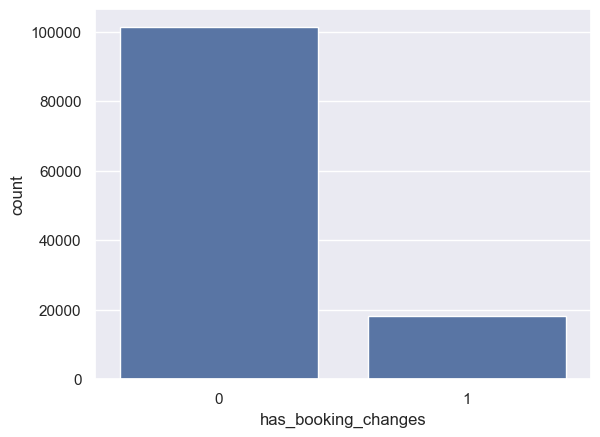

In [15]:
sns.countplot(x='has_booking_changes',data=df)

## Long Lead Booking Flag

Our EDA proved lead time is extremely important.

In [16]:
df['long_lead_booking'] = np.where(df['lead_time'] > 90, 1, 0)

<Axes: xlabel='long_lead_booking', ylabel='count'>

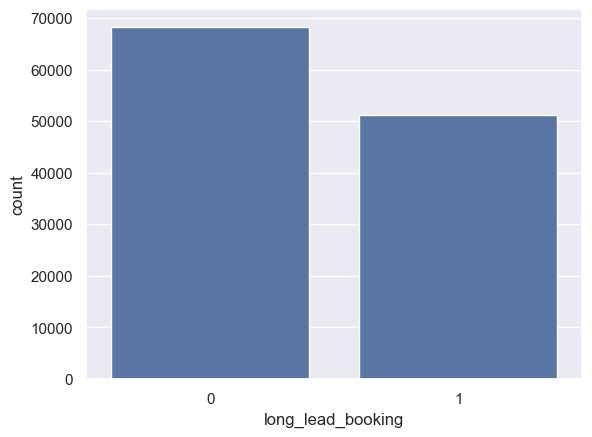

In [17]:
sns.countplot(x='long_lead_booking',data=df)

## Peak Season Flag

Creating seasonal demand indicator

In [18]:
peak_months = ['June', 'July', 'August']

df['is_peak_season'] = np.where(
    df['arrival_date_month'].isin(peak_months),
    1,
    0
)

<Axes: xlabel='is_peak_season', ylabel='count'>

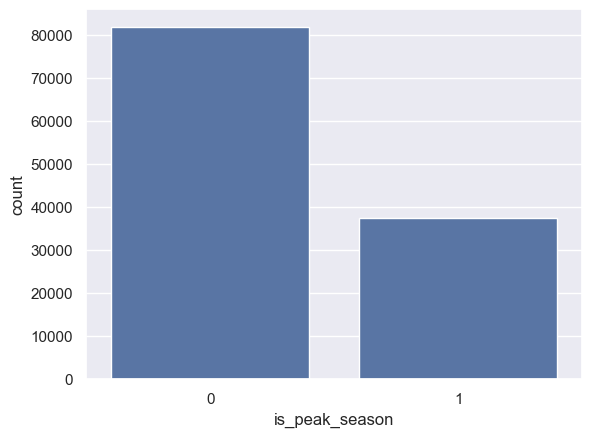

In [19]:
sns.countplot(x='is_peak_season',data=df)

## Room Change Flag

Very important operational feature, captures upgrades/downgrades/reallocation, strong operational signal

In [20]:
df['room_changed'] = np.where(
    df['reserved_room_type'] != df['assigned_room_type'],
    1,
    0
)

<Axes: xlabel='room_changed', ylabel='count'>

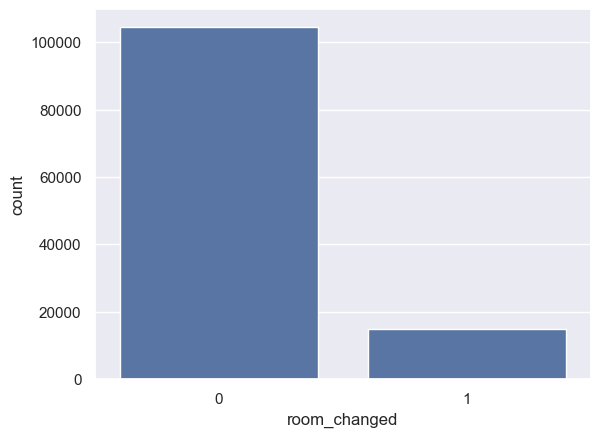

In [21]:
sns.countplot(x='room_changed',data=df)

## Deposit Risk Category

You can simplify deposit types, deposit type was one of the strongest cancellation predictors.

In [22]:
df['high_risk_deposit'] = np.where(
    df['deposit_type'] == 'Non Refund',
    1,
    0
)

<Axes: xlabel='high_risk_deposit', ylabel='count'>

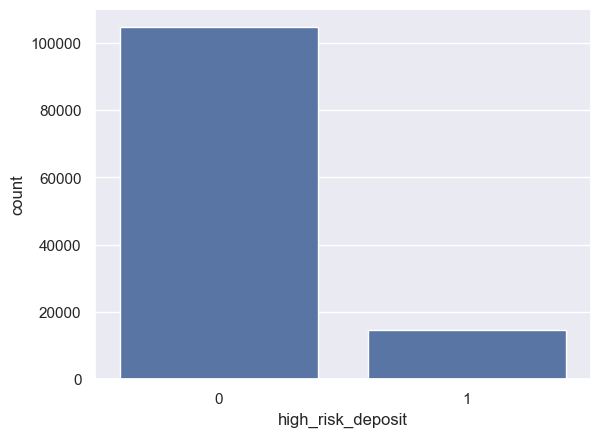

In [23]:
sns.countplot(x='high_risk_deposit',data=df)

## ADR Per Night

Normalize price by stay duration, removes stay-length bias, better pricing behavior indicator

In [24]:
df['adr_per_night'] = df['adr'] / (df['total_nights'] + 1)

<Axes: xlabel='adr_per_night', ylabel='Count'>

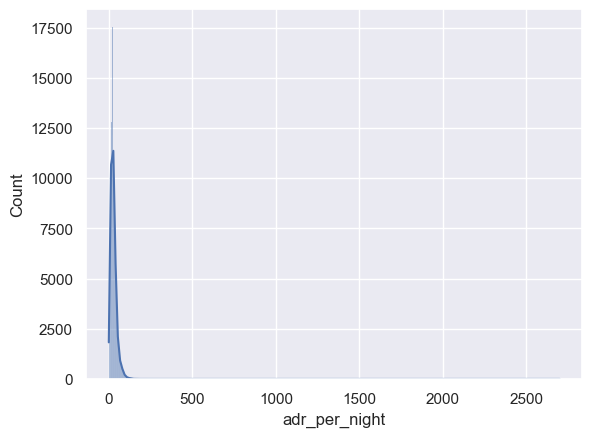

In [25]:
sns.histplot(data=df,x='adr_per_night',kde=True)

## Weekend Stay Ratio

Helps distinguish:

leisure travelers, business travelers

In [26]:
df['weekend_ratio'] = (
    df['stays_in_weekend_nights'] /
    (df['total_nights'] + 1)
)

<Axes: xlabel='weekend_ratio', ylabel='Count'>

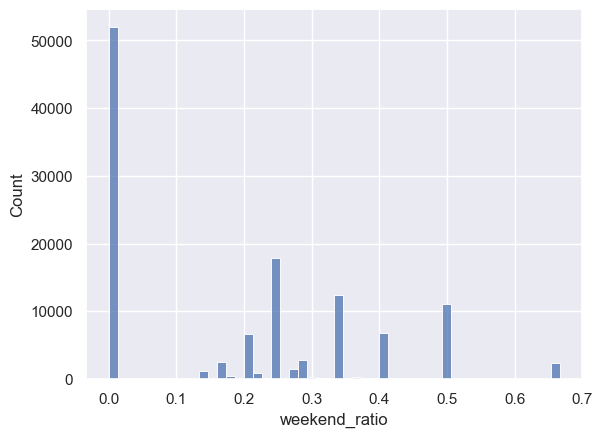

In [27]:
sns.histplot(x='weekend_ratio',data=df)

In [28]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'total_guests',
       'total_nights', 'is_family', 'prev_cancel_ratio', 'has_booking_changes',
       'long_lead_booking', 'is_peak_season', 'room_changed',
       'high_risk_deposit', 'adr_per_night', 'weekend_ratio'],
      dtype='str')

## Analysis of engineered features

### total_guests vs is_canceled

<Axes: xlabel='is_canceled', ylabel='total_guests'>

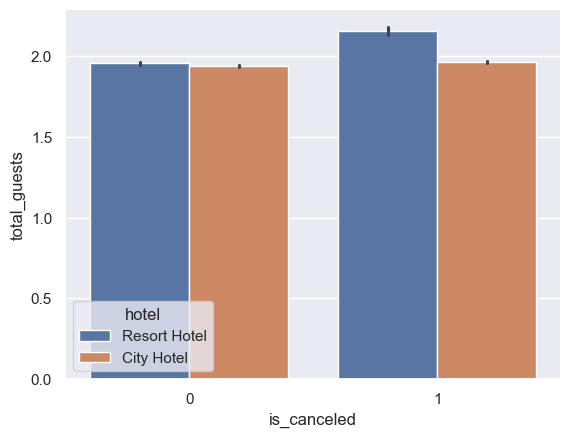

In [29]:
sns.barplot(x='is_canceled',y='total_guests',hue='hotel',data=df)

In [30]:
df.groupby(['is_canceled', 'hotel'])['total_guests'].agg(['count','min','max','mean','median','std']).round(2)

count  min   max  mean  median   std
is_canceled hotel                                             
0           City Hotel    46228  0.0  12.0  1.94     2.0  0.67
            Resort Hotel  28938  0.0   5.0  1.95     2.0  0.66
1           City Hotel    33098  0.0   5.0  1.96     2.0  0.58
            Resort Hotel  11122  0.0  55.0  2.15     2.0  1.23

The analysis of total_guests in relation to is_canceled reveals that guest occupancy size has only a limited influence on booking cancellations. Across both hotel types, the average number of guests remains highly stable around 2 occupants per booking, indicating that couple-based travel dominates the dataset regardless of cancellation behavior. City Hotels show almost identical guest distributions between canceled and non-canceled reservations, suggesting that occupancy size contributes very little predictive power in urban bookings. Resort Hotels, however, display a slightly higher average guest count among canceled reservations, implying that larger leisure or family-oriented group bookings may be somewhat more volatile. The extremely high maximum value observed in canceled Resort Hotel bookings also indicates the presence of rare outlier group reservations, which may represent bulk, corporate, or anomalous bookings. Overall, total_guests acts as a supportive contextual feature rather than a primary cancellation driver, with behavioral variables such as lead time, deposit type, and booking history remaining substantially more influential.

Feature Relevance Rating: Low to Moderate

## total_nights vs is_canceled

<Axes: xlabel='is_canceled', ylabel='total_nights'>

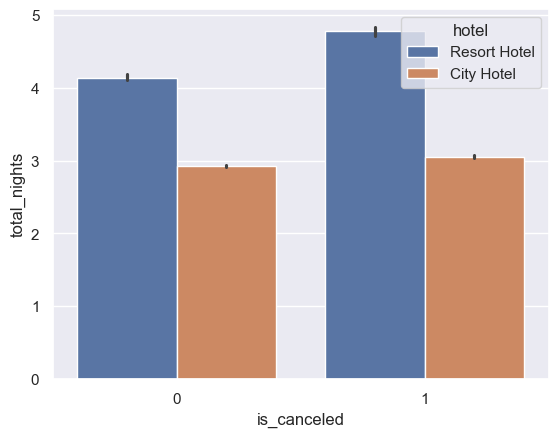

In [31]:
sns.barplot(y='total_nights',x='is_canceled',hue='hotel',data=df)

In [32]:
df.groupby(['is_canceled', 'hotel'])['total_nights'].agg(['count','min','max','mean','median','std']).round(2)

count  min  max  mean  median   std
is_canceled hotel                                            
0           City Hotel    46228    0   57  2.92     3.0  1.76
            Resort Hotel  28938    0   69  4.14     3.0  3.37
1           City Hotel    33102    0   33  3.05     3.0  1.99
            Resort Hotel  11122    0   56  4.78     4.0  3.35

The analysis of total_nights against is_canceled highlights meaningful differences in stay duration patterns across hotel types and booking outcomes. Resort Hotels consistently exhibit significantly longer stays than City Hotels, reflecting their strong association with leisure and vacation travel, while City Hotels remain dominated by shorter transient and business-oriented bookings. Canceled reservations show slightly higher average stay durations in both hotel categories, with the effect being particularly noticeable in Resort Hotels where canceled bookings average nearly five nights compared to just above four nights for successful stays. This suggests that longer vacation-oriented reservations carry greater uncertainty and are more susceptible to plan changes, itinerary adjustments, or financial reconsiderations. The large maximum stay values and high standard deviations further indicate the presence of extended-stay outliers, which may represent long vacations, group bookings, or exceptional reservation cases. Overall, total_nights demonstrates moderate predictive value, especially when combined with pricing, lead time, and customer behavior features, as stay duration alone does not fully explain cancellation behavior but clearly contributes to booking risk patterns.

Feature Relevance Rating: Moderate to High

## is_family vs is_canceled

In [33]:
pd.crosstab([df['is_canceled'],df['hotel']],df['is_family'],normalize='index')*100

is_family                         0          1
is_canceled hotel                             
0           City Hotel    92.340140   7.659860
            Resort Hotel  91.250259   8.749741
1           City Hotel    94.374962   5.625038
            Resort Hotel  87.439309  12.560691

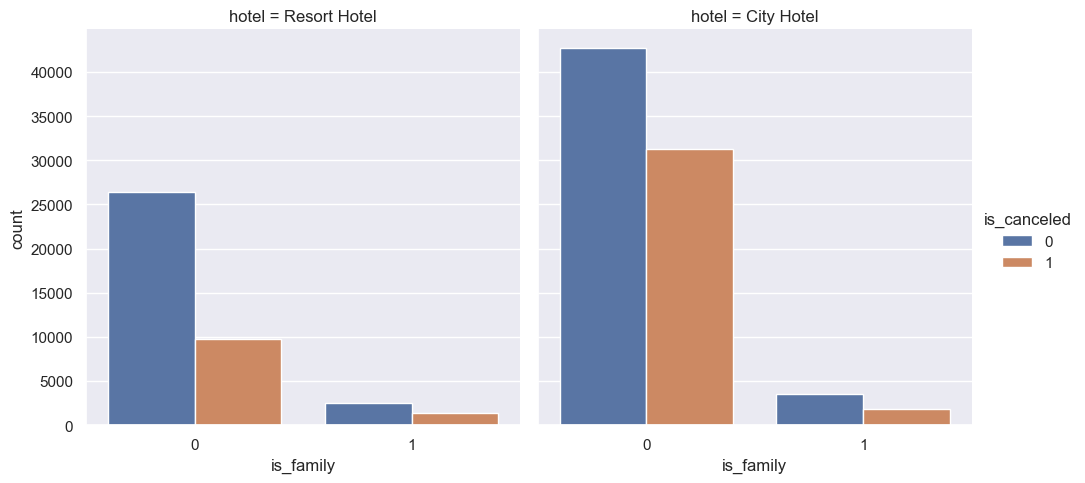

In [34]:
# Hotel-wise cancellation comparison
sns.catplot(
    x='is_family',
    hue='is_canceled',
    col='hotel',
    kind='count',
    data=df
)

The analysis of the engineered is_family feature reveals distinct behavioral differences between family and non-family travelers across hotel types. Non-family bookings overwhelmingly dominate the dataset in both City and Resort Hotels, confirming that the hotel demand structure is primarily driven by solo travelers, couples, and adult-only reservations. In City Hotels, canceled bookings contain a lower proportion of family travelers compared to successful reservations, suggesting that family-based urban travel tends to be relatively stable and less cancellation-prone. In contrast, Resort Hotels exhibit the opposite pattern, where family travelers account for a noticeably higher share of canceled reservations. This indicates that leisure-oriented family vacations may involve greater planning uncertainty, schedule changes, or financial flexibility, making them more susceptible to cancellation behavior. Although the overall differences are not extremely large, the feature provides meaningful segmentation value, particularly when analyzing Resort Hotel customer behavior.

Feature Relevance Rating:Moderate

## prev_cancel_ratio vs is_canceled

<Axes: xlabel='is_canceled', ylabel='prev_cancel_ratio'>

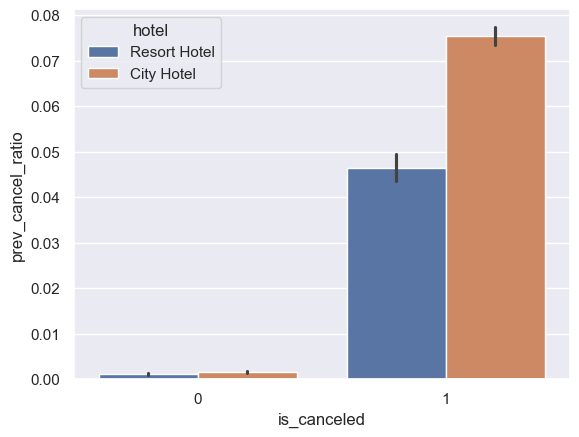

In [35]:
sns.barplot(x='is_canceled',y='prev_cancel_ratio',hue='hotel',data=df)


In [36]:
df.groupby(['is_canceled', 'hotel'])['prev_cancel_ratio'].agg(['count','min','max','mean','median','std']).round(2)


count  min   max  mean  median   std
is_canceled hotel                                             
0           City Hotel    46228  0.0  0.93  0.00     0.0  0.02
            Resort Hotel  28938  0.0  0.57  0.00     0.0  0.02
1           City Hotel    33102  0.0  0.95  0.08     0.0  0.18
            Resort Hotel  11122  0.0  0.96  0.05     0.0  0.16

The analysis of prev_cancel_ratio against is_canceled reveals one of the strongest behavioral patterns in the dataset. Non-canceled bookings across both City and Resort Hotels show near-zero average cancellation ratios, indicating that reliable customers typically have little to no prior cancellation history. In contrast, canceled reservations exhibit substantially higher average ratios, especially in City Hotels, where customers with previous cancellation behavior are significantly more likely to cancel again. This strongly supports the presence of habitual cancellation tendencies among certain customer groups. The high maximum values approaching 1 further indicate that some customers possess extremely poor booking reliability, having canceled most of their historical reservations. Despite the median remaining at zero due to the large number of first-time or low-history customers, the sharp increase in mean values and standard deviations among canceled bookings demonstrates that this feature captures highly valuable behavioral risk information. Overall, prev_cancel_ratio functions as a powerful customer reliability metric and stands out as one of the most predictive engineered features for cancellation modeling.

Feature Relevance Rating: Very High

In [37]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'total_guests',
       'total_nights', 'is_family', 'prev_cancel_ratio', 'has_booking_changes',
       'long_lead_booking', 'is_peak_season', 'room_changed',
       'high_risk_deposit', 'adr_per_night', 'weekend_ratio'],
      dtype='str')

## has_booking_changes vs is canceled

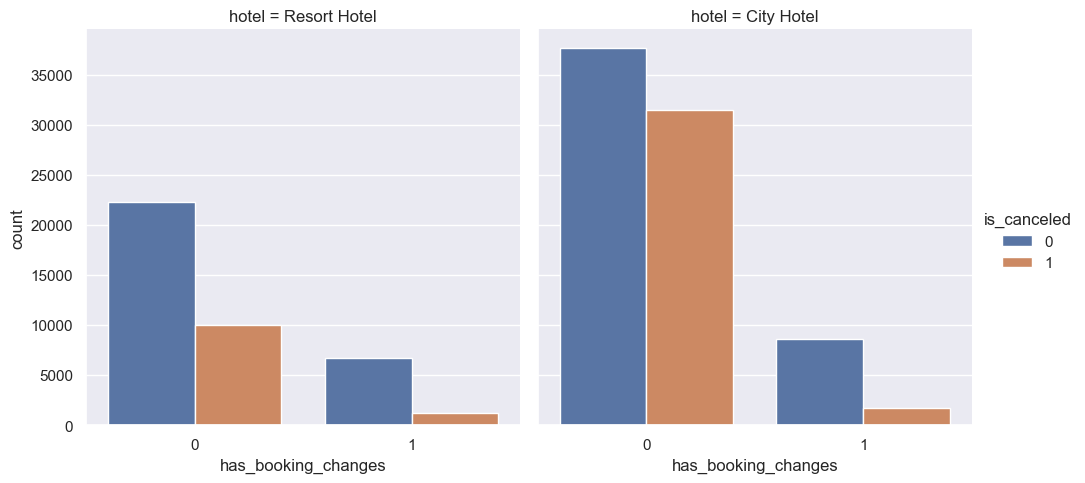

In [38]:
sns.catplot(
    x='has_booking_changes',
    hue='is_canceled',
    col='hotel',
    kind='count',
    data=df
)


In [39]:
pd.crosstab([df['is_canceled'],df['hotel']],df['has_booking_changes'],normalize='index')*100

has_booking_changes               0          1
is_canceled hotel                             
0           City Hotel    81.420351  18.579649
            Resort Hotel  77.006013  22.993987
1           City Hotel    94.927799   5.072201
            Resort Hotel  89.624168  10.375832

The engineered feature prev_cancel_ratio demonstrates extremely strong predictive behavior in relation to booking cancellations. Customers associated with successful reservations exhibit almost zero historical cancellation tendency, while canceled bookings show significantly elevated cancellation ratios across both hotel types. This pattern clearly indicates that prior booking behavior is highly indicative of future customer actions, confirming the presence of recurring cancellation habits among certain travelers. The difference is especially pronounced in City Hotels, where canceled reservations are associated with the highest average cancellation ratios. Although the median remains zero due to the large proportion of customers without prior booking history, the substantial rise in mean values and variability among canceled reservations highlights the feature’s ability to isolate high-risk customers effectively. Overall, this feature captures customer reliability exceptionally well and provides a direct behavioral signal strongly linked to cancellation probability.

Feature Relevance Rating: Very High

## long_lead_booking vs is_canceled

In [40]:
pd.crosstab([df['is_canceled'],df['hotel']],df['long_lead_booking'],normalize='index')*100

long_lead_booking                 0          1
is_canceled hotel                             
0           City Hotel    66.323440  33.676560
            Resort Hotel  66.601009  33.398991
1           City Hotel    40.780013  59.219987
            Resort Hotel  43.400468  56.599532

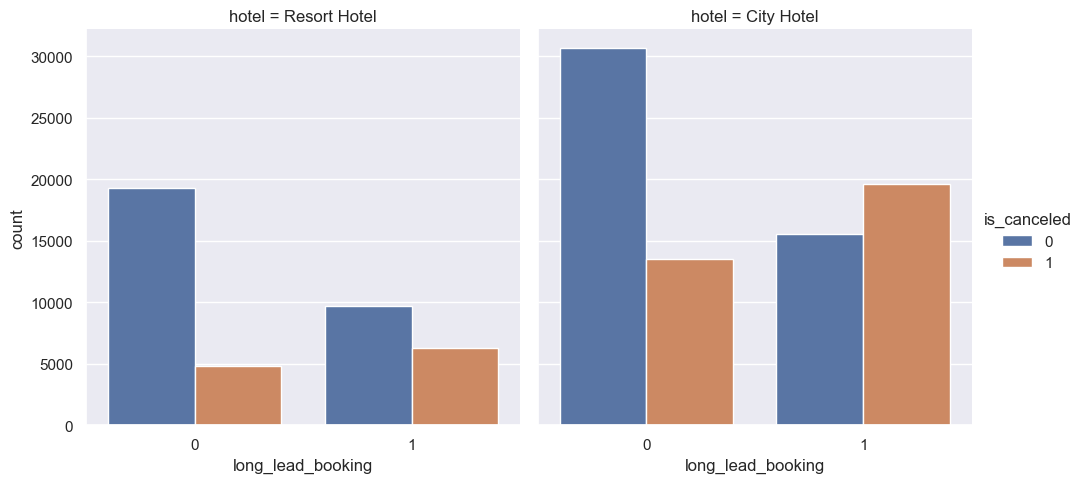

In [41]:
sns.catplot(
    x='long_lead_booking',
    hue='is_canceled',
    col='hotel',
    kind='count',
    data=df
)


The analysis of long_lead_booking reveals a very strong relationship between advance booking duration and cancellation behavior across both hotel types. Non-canceled reservations are predominantly associated with shorter booking lead times, with roughly two-thirds of successful bookings being made within the shorter lead-time category. In contrast, canceled reservations are heavily concentrated among long lead bookings, where more than half of cancellations originate from reservations made far in advance. This pattern is consistent across both City and Resort Hotels, confirming that customers who book several months ahead are significantly more likely to change plans, adjust travel schedules, or cancel reservations before arrival. The findings strongly align with earlier EDA observations showing lead time as one of the most influential behavioral variables in the dataset. Overall, long_lead_booking effectively captures booking uncertainty and serves as a highly informative cancellation-risk indicator.

Feature Relevance Rating: Very High

## is_peak_season vs is_canceled

In [42]:
pd.crosstab([df['is_canceled'],df['hotel']],df['is_peak_season'],normalize='index')*100

is_peak_season                    0          1
is_canceled hotel                             
0           City Hotel    68.570996  31.429004
            Resort Hotel  70.861843  29.138157
1           City Hotel    68.473204  31.526796
            Resort Hotel  63.315950  36.684050

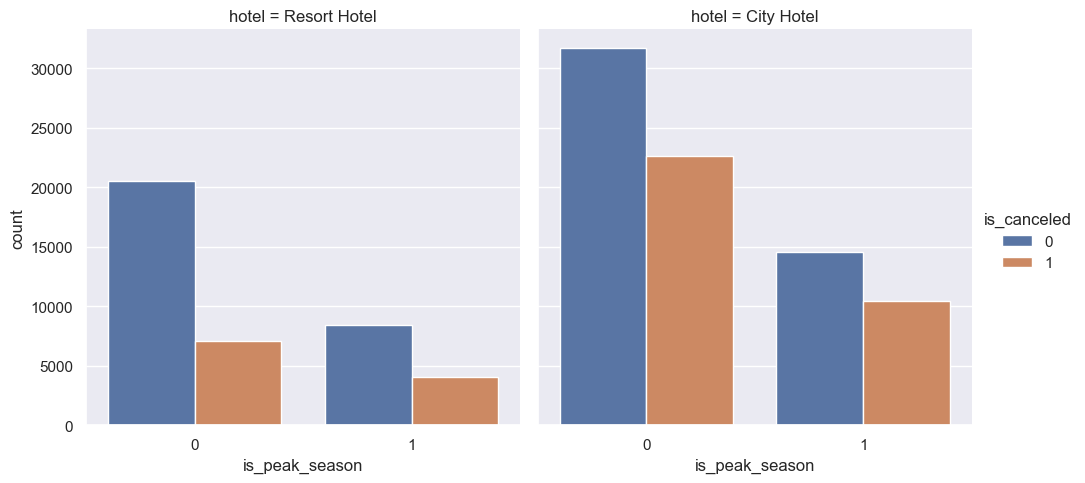

In [43]:
sns.catplot(
    x='is_peak_season',
    hue='is_canceled',
    col='hotel',
    kind='count',
    data=df
)

The analysis of is_peak_season indicates that seasonality has a relatively moderate impact on cancellation behavior, with stronger effects observed in Resort Hotels compared to City Hotels. In City Hotels, the distribution between peak-season and non-peak-season bookings remains almost identical for canceled and non-canceled reservations, suggesting that seasonal demand contributes little additional predictive value in urban travel environments. Resort Hotels, however, show a noticeable increase in cancellations during peak travel periods, where canceled reservations contain a higher proportion of peak-season bookings compared to successful stays. This pattern suggests that leisure-oriented vacation travel during high-demand months is more prone to schedule changes, pricing sensitivity, and booking uncertainty. The findings also align with earlier EDA insights showing increased seasonal demand and ADR fluctuations during summer travel periods. Overall, while seasonality alone is not a dominant cancellation driver, it provides useful contextual information, particularly for resort-based leisure travel behavior.

Feature Relevance Rating: Moderate

In [44]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'total_guests',
       'total_nights', 'is_family', 'prev_cancel_ratio', 'has_booking_changes',
       'long_lead_booking', 'is_peak_season', 'room_changed',
       'high_risk_deposit', 'adr_per_night', 'weekend_ratio'],
      dtype='str')

## room_changed vs is_canceled

In [45]:
pd.crosstab([df['is_canceled'],df['hotel']],df['room_changed'],normalize='index')*100

room_changed                      0          1
is_canceled hotel                             
0           City Hotel    85.346543  14.653457
            Resort Hotel  74.631972  25.368028
1           City Hotel    98.737236   1.262764
            Resort Hotel  96.547384   3.452616

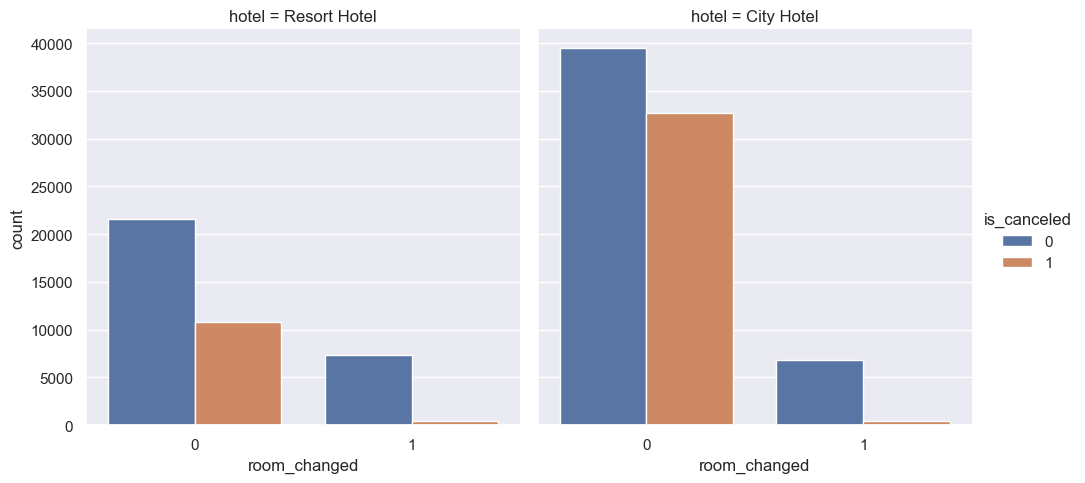

In [46]:
sns.catplot(
    x='room_changed',
    hue='is_canceled',
    col='hotel',
    kind='count',
    data=df
)

The analysis of room_changed reveals a strong operational relationship with booking cancellations across both hotel types. Non-canceled reservations show a significantly higher proportion of room changes, particularly in Resort Hotels, where operational reallocations, upgrades, or room adjustments appear relatively common among successfully completed stays. In contrast, canceled bookings overwhelmingly consist of reservations where no room change occurred, with only a very small fraction experiencing reassignment before cancellation. This pattern is logical from an operational perspective, as room allocation adjustments generally happen closer to check-in or during active reservation management, whereas canceled bookings often terminate before such processes occur. The results suggest that customers whose bookings progress far enough to undergo room reassignment are substantially more likely to complete their stay. Overall, room_changed acts as a meaningful behavioral and operational engagement signal, strongly associated with lower cancellation probability.

Feature Relevance Rating: High

## high_risk_deposit vs is_canceled

In [47]:
pd.crosstab([df['is_canceled'],df['hotel']],df['high_risk_deposit'],normalize='index')*100

high_risk_deposit                 0          1
is_canceled hotel                             
0           City Hotel    99.948083   0.051917
            Resort Hotel  99.761559   0.238441
1           City Hotel    61.198719  38.801281
            Resort Hotel  85.164539  14.835461

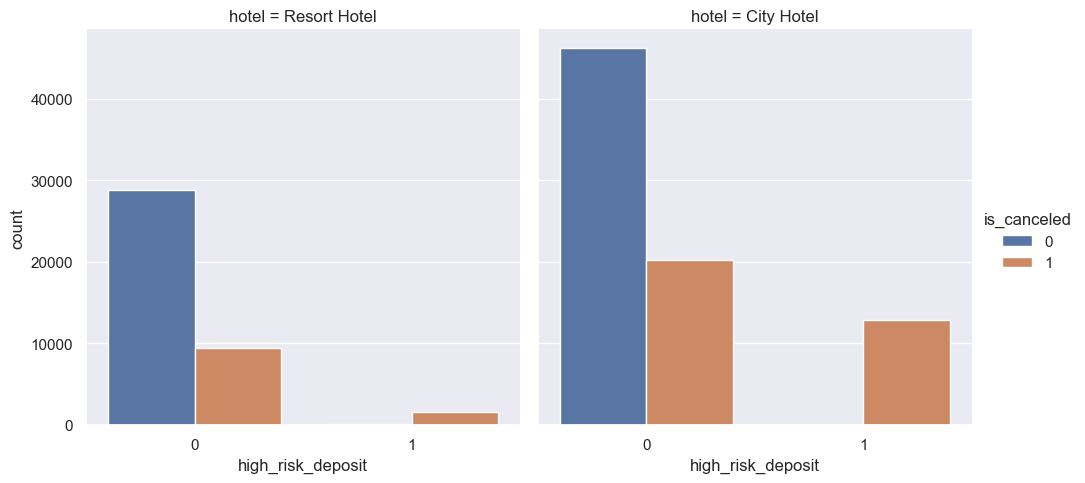

In [48]:
sns.catplot(
    x='high_risk_deposit',
    hue='is_canceled',
    col='hotel',
    kind='count',
    data=df
)


The analysis of high_risk_deposit demonstrates one of the strongest relationships with booking cancellations in the entire dataset. Non-canceled reservations across both City and Resort Hotels almost never involve high-risk non-refundable deposit types, indicating that successful bookings are overwhelmingly associated with flexible payment structures. In contrast, canceled bookings show a dramatic increase in high-risk deposits, particularly in City Hotels where nearly 39% of canceled reservations belong to the non-refundable category. Resort Hotels also exhibit elevated cancellation proportions for such deposits, although the effect is less extreme than in urban properties. This pattern strongly suggests that deposit structure is closely tied to customer booking behavior, pricing strategies, and reservation risk segmentation. The findings confirm earlier EDA results identifying deposit type as a critical behavioral feature with major influence on cancellation probability. Overall, high_risk_deposit acts as an exceptionally powerful risk indicator and provides highly valuable predictive information for cancellation modeling.

Feature Relevance Rating: Very High

## adr_per_night vs is_canceled

In [49]:
df.groupby(['is_canceled', 'hotel'])['adr_per_night'].agg(['count','min','max','mean','median','std']).round(2)

count   min     max   mean  median    std
is_canceled hotel                                                  
0           City Hotel    46228  0.00   255.0  31.40   27.60  18.28
            Resort Hotel  28938 -0.58   254.0  22.94   18.05  19.12
1           City Hotel    33102  0.00  2700.0  29.52   25.25  21.10
            Resort Hotel  11122  0.00   191.0  22.85   18.00  18.24

<Axes: xlabel='is_canceled', ylabel='adr_per_night'>

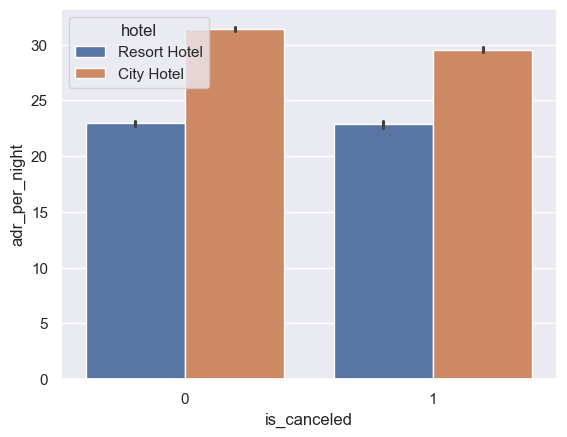

In [50]:
sns.barplot(x='is_canceled',y='adr_per_night',hue='hotel',data=df)

The analysis of adr_per_night against is_canceled reveals meaningful pricing and revenue-related booking patterns across both hotel categories. City Hotels consistently exhibit higher average nightly rates than Resort Hotels, reflecting their stronger association with business travel, urban demand, and dynamic pricing behavior. Interestingly, canceled bookings in City Hotels show slightly lower average ADR values compared to successful reservations, suggesting that lower-priced urban bookings may be more flexible and easier for customers to abandon. Resort Hotels, however, display relatively stable ADR patterns between canceled and non-canceled reservations, indicating that nightly pricing alone is not a dominant cancellation driver in leisure-focused stays. The extremely high maximum ADR values observed among canceled City Hotel bookings also highlight the presence of substantial pricing outliers, which may represent luxury reservations, data anomalies, or exceptional high-demand periods. Additionally, the negative minimum value in Resort Hotels suggests the existence of rare data inconsistencies or adjustment-related records that may require cleaning before modeling. Overall, adr_per_night provides valuable revenue and pricing context, especially when combined with behavioral and seasonal variables.

Feature Relevance Rating: Moderate to High

## weekend_ratio vs is_canceled

In [51]:
df.groupby(['is_canceled', 'hotel'])['weekend_ratio'].agg(['count','min','max','mean','median','std']).round(2)

count  min   max  mean  median   std
is_canceled hotel                                             
0           City Hotel    46228  0.0  0.67  0.19    0.20  0.20
            Resort Hotel  28938  0.0  0.67  0.19    0.25  0.17
1           City Hotel    33102  0.0  0.67  0.17    0.17  0.19
            Resort Hotel  11122  0.0  0.67  0.21    0.25  0.16

<Axes: xlabel='is_canceled', ylabel='weekend_ratio'>

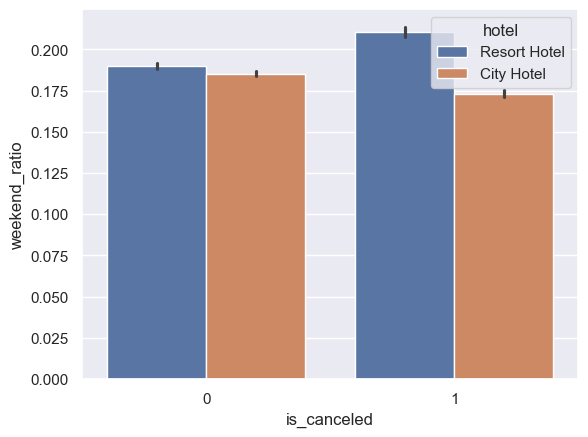

In [52]:
sns.barplot(x='is_canceled',y='weekend_ratio',hue='hotel',data=df)

The analysis of weekend_ratio against is_canceled reveals subtle but meaningful differences in travel behavior across hotel types. Both City and Resort Hotels show relatively balanced weekend-to-total-stay proportions, indicating that most reservations contain a mix of weekday and weekend nights rather than being purely weekend-focused. In City Hotels, canceled bookings exhibit a slightly lower average weekend ratio compared to successful reservations, suggesting that weekday-dominant or business-oriented trips may experience marginally higher cancellation tendencies. Resort Hotels display the opposite behavior, where canceled bookings contain a slightly higher weekend proportion, reflecting the greater uncertainty associated with leisure and vacation travel concentrated around weekends. However, the differences remain relatively small overall, indicating that weekend stay composition alone is not a major cancellation driver. Instead, the feature provides useful contextual insight into customer travel intent and complements broader behavioral and seasonal patterns identified during EDA.

Feature Relevance Rating: Moderate

In [53]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'total_guests',
       'total_nights', 'is_family', 'prev_cancel_ratio', 'has_booking_changes',
       'long_lead_booking', 'is_peak_season', 'room_changed',
       'high_risk_deposit', 'adr_per_night', 'weekend_ratio'],
      dtype='str')

# Feature Engineering Summary

The feature engineering phase significantly enhanced the analytical and predictive strength of the hotel booking dataset by transforming raw operational variables into more meaningful behavioral, pricing, temporal, and customer-risk indicators. The newly engineered features were specifically designed to capture booking intent, customer reliability, travel structure, pricing behavior, and reservation commitment — all of which emerged as critical drivers during exploratory data analysis.

Behavioral features such as `prev_cancel_ratio`, `long_lead_booking`, and `high_risk_deposit` proved to be exceptionally powerful predictors of booking cancellations, clearly distinguishing high-risk customers from reliable travelers. These variables successfully transformed historical customer actions and booking policies into normalized risk signals, making them highly informative for machine learning classification tasks.

Travel-structure features including `total_guests`, `total_nights`, `is_family`, and `weekend_ratio` helped capture differences between leisure, business, and family-oriented travel behavior. While these variables demonstrated moderate standalone predictive power, they provided valuable contextual information that improves customer segmentation and interaction modeling.

Operational features such as `room_changed` and `has_booking_changes` introduced insights into reservation maturity and customer engagement behavior. The analysis revealed that bookings progressing deeper into operational allocation stages were significantly less likely to cancel, highlighting the importance of reservation activity patterns.

Revenue-related transformations like `adr_per_night` improved the interpretability of pricing behavior by normalizing ADR against stay duration, making pricing signals more stable and meaningful for predictive modeling. Seasonal indicators such as `is_peak_season` further contributed contextual demand-related information, particularly for Resort Hotel bookings.

Overall, the feature engineering process successfully reduced raw-data limitations, improved feature interpretability, minimized sparsity in certain variables, and created several high-signal predictors strongly aligned with real-world hotel booking behavior.

---

# Final Conclusion

The complete EDA and feature engineering process establishes that hotel booking cancellations are primarily driven by **behavioral and booking-management factors rather than demographic characteristics**. Variables related to customer reliability, booking lead time, deposit structure, pricing behavior, and reservation commitment consistently demonstrated the strongest predictive relationships with cancellation outcomes.

The analysis clearly shows that:

* Long advance bookings carry substantially higher cancellation risk
* Customers with prior cancellation history are highly likely to cancel again
* Deposit policies strongly influence booking reliability
* OTA/group-related reservations exhibit higher volatility
* Resort and City Hotels display distinct behavioral cancellation patterns
* Operational engagement signals help distinguish committed reservations from unstable bookings

The engineered dataset is now highly suitable for machine learning classification tasks such as:

* Booking cancellation prediction
* Customer risk scoring
* Revenue optimization
* Dynamic pricing support
* Reservation management systems

The final feature set contains a strong balance of:

* behavioral signals
* operational indicators
* pricing features
* temporal variables
* customer segmentation attributes

making it well-prepared for robust predictive modeling.

---

# Final Recommended Features for Classification

After removing redundant, leakage-prone, overly sparse, or low-value columns, the following features are recommended for the final classification model.

---

# Target Variable

```python id="6e7c9z"
target = 'is_canceled'
```

---

# Final Recommended Feature List

```python id="vktj4t"
final_features = [

    # Hotel & Time Features
    'hotel',
    'lead_time',
    'arrival_date_month',
    'arrival_date_week_number',

    # Stay Structure
    'total_nights',
    'weekend_ratio',

    # Guest Information
    'total_guests',
    'is_family',

    # Booking Behavior
    'market_segment',
    'distribution_channel',
    'customer_type',
    'repeat_customer',
    'prev_cancel_ratio',
    'long_lead_booking',
    'has_booking_changes',

    # Operational Features
    'room_changed',

    # Financial Features
    'adr_per_night',
    'high_risk_deposit',

    # Customer Interaction
    'required_car_parking_spaces',
    'total_of_special_requests'

]
```

---

# Features Removed and Why

| Removed Feature                  | Reason                                           |
| -------------------------------- | ------------------------------------------------ |
| `reservation_status`             | Massive data leakage                             |
| `reservation_status_date`        | Leakage                                          |
| `assigned_room_type`             | Replaced by `room_changed`                       |
| `reserved_room_type`             | Lower signal than engineered version             |
| `stays_in_week_nights`           | Redundant after `total_nights`                   |
| `stays_in_weekend_nights`        | Redundant after `total_nights` + `weekend_ratio` |
| `adults`, `children`, `babies`   | Replaced by `total_guests` and `is_family`       |
| `previous_cancellations`         | Replaced by `prev_cancel_ratio`                  |
| `previous_bookings_not_canceled` | Replaced by `prev_cancel_ratio`                  |
| `booking_changes`                | Replaced by `has_booking_changes`                |
| `deposit_type`                   | Replaced by `high_risk_deposit`                  |
| `adr`                            | Replaced by `adr_per_night`                      |
| `arrival_date_day_of_month`      | Weak predictive power                            |
| `arrival_date_year`              | Limited variability                              |
| `meal`                           | Weak signal                                      |
| `country`                        | High cardinality                                 |
| `agent`                          | Extremely high cardinality                       |
| `company`                        | Sparse + high cardinality                        |
| `days_in_waiting_list`           | Weak practical signal                            |
| `is_repeated_guest`              | Replaced by `repeat_customer`                    |
| `is_peak_season`                 | Lower signal than other temporal features        |

---

# Expected Strongest Predictors

Based on complete EDA + feature engineering:

| Expected Importance | Feature                   |
| ------------------- | ------------------------- |
| ⭐⭐⭐⭐⭐               | prev_cancel_ratio         |
| ⭐⭐⭐⭐⭐               | long_lead_booking         |
| ⭐⭐⭐⭐⭐               | high_risk_deposit         |
| ⭐⭐⭐⭐                | lead_time                 |
| ⭐⭐⭐⭐                | adr_per_night             |
| ⭐⭐⭐⭐                | market_segment            |
| ⭐⭐⭐⭐                | room_changed              |
| ⭐⭐⭐⭐                | total_of_special_requests |
| ⭐⭐⭐                 | total_nights              |
| ⭐⭐⭐                 | customer_type             |


## saving the new dataset

In [54]:
df.to_csv(r"D:\Shorya\VScode\hotel booking\hotel_booking_fe.csv", index=False)